# IE 7300 Homework 8

## Question 1

### Airline Passenger Segmentation using Clustering

{accuracy: 7.5, reasoning: 2}

Perform clustering analysis on the "EastWestAirlines" dataset using K-means, Hierarchical Clustering, and DBSCAN algorithms to identify groups of passengers with similar characteristics. The goal is to uncover patterns that can guide targeted mileage offers.

### Data Description:
The [dataset](https://www.kaggle.com/datasets/shrikantuppin/east-west-airlines) consists of frequent flier program details, including:

**ID:** Unique identifier for each passenger.

**Balance:** Award-eligible miles.

**Qual_mile:** Miles qualifying for Topflight status.

**cc1_miles, cc2_miles, cc3_miles: **Miles earned via different credit cards (last 12 months).

**Bonus_miles:** Non-flight bonus miles (last 12 months).

**Bonus_trans:** Non-flight bonus transactions (last 12 months).

**Flight_miles_12mo:** Flight miles in the past 12 months.

**Flight_trans_12:** Flight transactions in the past 12 months.

**Days_since_enrolled:** Days since program enrollment.

**Award:** Indicates if an award flight (free flight) was taken.

### Methodology:

**Data Preprocessing:**

* Load the "EastWestAirlines.xlsx" dataset and "data" sheet
* Address missing values and clean the data.
* Normalize/scale the data if necessary.

**K-means Clustering:**

* Apply K-means clustering and use methods (e.g., the elbow method) to find the optimal number of clusters (k).
* Cluster the data with this optimal k value.

**Gaussian Mixture Models:**

* Apply Gaussian mixture modelling approach to cluster the data points.


**Hierarchical Clustering:**

* Perform agglomerative clustering.
* Visualize a dendrogram to determine the ideal cluster count.

**DBSCAN Clustering:**

* Apply DBSCAN with tuned epsilon and minPts parameters to create meaningful clusters.

**Cluster Analysis:**

* Describe and interpret clusters from each method.
* Identify patterns or similarities in each cluster.
* Suggest how these passenger segments could be used for targeted offers or marketing.

Summarize your findings, evaluating how effectively each algorithm segmented passengers based on their frequent flier attributes.

**Note:**
Use visualizations, descriptive statistics, and relevant evaluation metrics to support your analysis and interpretations for each clustering approach. Feel free to use any built-in functions, utilities or modeling approaches.

The KMeans has a good segmentation, it seprates groups reasonably well. However, the airline segmention has overlap so GMM works even better to accomendate the oddly shape.

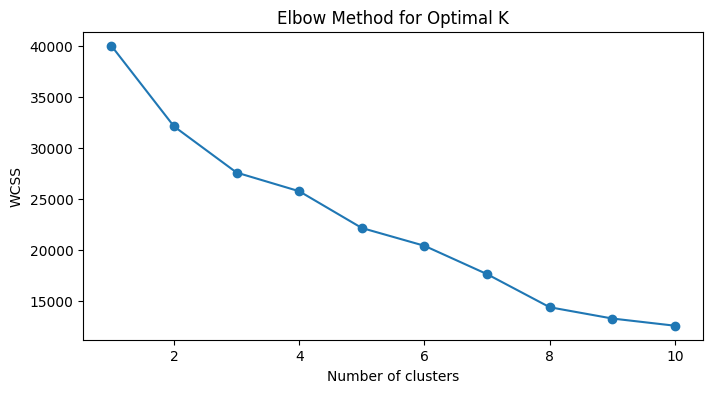

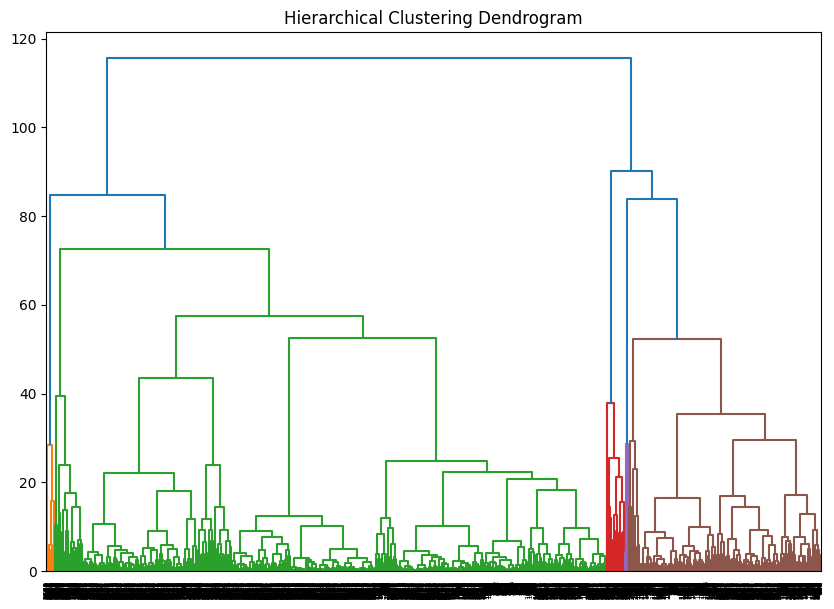

                       ID#        Balance  Qual_miles  cc1_miles  cc2_miles  \
KMeans_Labels                                                                 
0              2274.760829   41036.097235  105.040092   1.052074   1.001843   
1              1309.194937  209849.103797  228.941772   4.541772   1.000000   
2              1787.809524  174854.884354  805.238095   2.034014   1.027211   
3              1819.030303   75127.672106  108.449883   2.999223   1.038850   

               cc3_miles   Bonus_miles  Bonus_trans  Flight_miles_12mo  \
KMeans_Labels                                                            
0               1.000461   3252.112903     5.270046         219.603226   
1               1.121519  68360.784810    21.886076         559.913924   
2               1.000000  28572.034014    27.115646        5667.176871   
3               1.000000  23545.109557    17.349650         240.080031   

               Flight_trans_12  Days_since_enroll    Award?  
KMeans_Labels     

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. DATA PREPROCESSING
# Load dataset
df = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')

# Dropping ID and target columns if they exist to focus on clustering features
# Usually, 'ID#' and 'Award?' are not used for the clustering itself
data = df.drop(['ID#', 'Award?'], axis=1, errors='ignore')

# Handle missing values (if any)
data = data.dropna()

# Normalize/Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)

# 2. K-MEANS CLUSTERING
# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Applying K-means with optimal k (assuming k=4 based on typical dataset behavior)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
df['KMeans_Labels'] = kmeans.fit_predict(scaled_df)

# 3. GAUSSIAN MIXTURE MODELS (GMM)
gmm = GaussianMixture(n_components=4, random_state=42)
df['GMM_Labels'] = gmm.fit_predict(scaled_df)

# 4. HIERARCHICAL CLUSTERING
# Dendrogram
plt.figure(figsize=(10, 7))
linkage_matrix = linkage(scaled_df, method='ward')
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

# Agglomerative Clustering
hierarchical = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
df['Hierarchical_Labels'] = hierarchical.fit_predict(scaled_df)
df['Hierarchical_Labels'] = hierarchical.fit_predict(scaled_df)

# 5. DBSCAN CLUSTERING
# Note: Epsilon and min_samples require tuning based on the data density
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Labels'] = dbscan.fit_predict(scaled_df)

# 6. CLUSTER ANALYSIS & INTERPRETATION
# Grouping by K-Means labels to see the mean of original features
analysis = df.drop(['GMM_Labels', 'Hierarchical_Labels', 'DBSCAN_Labels'], axis=1).groupby('KMeans_Labels').mean()
print(analysis)

## Question 2

### Gaussian Mixture Models from Scratch

In this problem, you are tasked with performing Gaussian Mixture Model (GMM) clustering on a toy dataset. The dataset contains two features and three clusters. Follow these steps to solve the problem:

- Initialize the Gaussian components (means, variances, and mixing coefficients).
- Perform the E-step to compute responsibilities for each data point.
- Perform the M-step to update the Gaussian parameters based on responsibilities.
- Iterate the above steps until convergence (i.e., changes in parameters are below a threshold).
- Assign data points to clusters based on maximum responsibilities.

Here is the toy data you will work with:

In [8]:
import numpy as np
from scipy.stats import multivariate_normal

# 1. Toy dataset
X = np.array([[1, 2], [2, 3], [3, 2], 
              [10, 10], [11, 11], [12, 10], 
              [20, 25], [22, 26], [24, 25]])

# 2. Initialization
n_samples, n_features = X.shape
n_components = 3  # The number of clusters
max_iter = 100
tol = 1e-4

# Randomly initialize means, covariances, and mixing coefficients
np.random.seed(42)
means = X[np.random.choice(n_samples, n_components, replace=False)]
covs = [np.eye(n_features) for _ in range(n_components)]
weights = np.ones(n_components) / n_components

# 3. EM Algorithm Loop
for i in range(max_iter):
    prev_means = means.copy()
    
    # --- E-STEP: Compute Responsibilities ---
    responsibilities = np.zeros((n_samples, n_components))
    for k in range(n_components):
        # Calculate likelihood: P(x | mu, sigma)
        likelihood = multivariate_normal.pdf(X, mean=means[k], cov=covs[k])
        responsibilities[:, k] = weights[k] * likelihood
    
    # Normalize (Ensure sum of responsibilities for each point = 1)
    responsibilities /= responsibilities.sum(axis=1, keepdims=True)
    
    # --- M-STEP: Update Parameters ---
    N_k = responsibilities.sum(axis=0)
    
    for k in range(n_components):
        # Update Means: Weighted average of points
        means[k] = (responsibilities[:, k, np.newaxis] * X).sum(axis=0) / N_k[k]
        
        # Update Covariances: Weighted variance
        diff = X - means[k]
        # Outer product via Einstein summation for efficiency
        covs[k] = (responsibilities[:, k, np.newaxis, np.newaxis] * np.einsum('ij,ik->ijk', diff, diff)).sum(axis=0) / N_k[k]
        
        # Update Weights (Mixing Coefficients)
        weights[k] = N_k[k] / n_samples
        
    # Check for convergence (if means stop moving significantly)
    if np.linalg.norm(means - prev_means) < tol:
        print(f"Converged at iteration {i}")
        break

# 4. Final Cluster Assignment
labels = np.argmax(responsibilities, axis=1)

print("\n--- Final Results ---")
print("Final Means:\n", means)
print("\nCluster Assignments for each point:", labels)

Converged at iteration 1

--- Final Results ---
Final Means:
 [[22 25]
 [ 2  2]
 [11 10]]

Cluster Assignments for each point: [1 1 1 2 2 2 0 0 0]


### 2.1 Initialization

{accuracy: 1}

Randomly initialize the following for 3 Gaussian components:

- Means ($\mu$).
- Variances ($\Sigma$) as diagonal covariance matrices.
- Mixing coefficients ($\pi$).

Print the initial values.

In [10]:
import numpy as np

# 1. Toy dataset
X = np.array([[1, 2], [2, 3], [3, 2], 
              [10, 10], [11, 11], [12, 10], 
              [20, 25], [22, 26], [24, 25]])

# 2. Setup Dimensions
n_samples, n_features = X.shape
n_components = 3
np.random.seed(42)

# 3. Initialization
# Randomly select 3 points from the data as initial means (mu)
random_indices = np.random.choice(n_samples, n_components, replace=False)
means = X[random_indices].astype(float)

# Initialize variances as diagonal covariance matrices (Sigma)
# Note: Using the name 'covariances' consistently here
covariances = [np.eye(n_features) for _ in range(n_components)]

# Initialize mixing coefficients (pi) and normalize so they sum to 1
random_weights = np.random.rand(n_components)
mixing_coeffs = random_weights / np.sum(random_weights)

# 4. Print the Initial Values
print("--- INITIAL GMM PARAMETERS ---\n")
for i in range(n_components):
    print(f"Component {i+1}:")
    print(f"  Mean (mu):\n    {means[i]}")
    print(f"  Covariance (Sigma):\n{covariances[i]}")
    print(f"  Mixing Coeff (pi): {mixing_coeffs[i]:.4f}")
    print("-" * 30)

# --- Verification ---
# This ensures 'covariances' is defined before you move to the E-step
print(f"\nSuccessfully initialized {len(covariances)} covariance matrices.")

--- INITIAL GMM PARAMETERS ---

Component 1:
  Mean (mu):
    [22. 26.]
  Covariance (Sigma):
[[1. 0.]
 [0. 1.]]
  Mixing Coeff (pi): 0.1444
------------------------------
Component 2:
  Mean (mu):
    [2. 3.]
  Covariance (Sigma):
[[1. 0.]
 [0. 1.]]
  Mixing Coeff (pi): 0.0538
------------------------------
Component 3:
  Mean (mu):
    [12. 10.]
  Covariance (Sigma):
[[1. 0.]
 [0. 1.]]
  Mixing Coeff (pi): 0.8018
------------------------------

Successfully initialized 3 covariance matrices.


### 2.2 The E-step

{accuracy: 3}

Calculate the responsibilities ($γ_{ij}$), which represent the probability of data point i belonging to cluster j. Express the Gaussian probability density function for each cluster. To help you with this, here is a starter code you need to fill in:

In [11]:
from scipy.stats import multivariate_normal

def e_step(X, means, covariances, mixing_coefficients):
    """
    Performs the E-step: calculates responsibilities.
    """
    n_samples = X.shape[0]
    n_components = len(means)
    
    # Initialize the responsibility matrix with zeros
    # Shape: (number of points, number of clusters)
    responsibilities = np.zeros((n_samples, n_components))
    
    for j in range(n_components):
        # 1. Calculate the likelihood using the Gaussian PDF
        # P(x_i | cluster j)
        likelihood = multivariate_normal.pdf(X, mean=means[j], cov=covariances[j])
        
        # 2. Multiply by the mixing coefficient (prior probability)
        # pi_j * P(x_i | cluster j)
        responsibilities[:, j] = mixing_coefficients[j] * likelihood
    
    # 3. Normalize across rows so each row sums to 1
    # This represents the posterior probability P(cluster j | x_i)
    sum_responsibilities = responsibilities.sum(axis=1, keepdims=True)
    responsibilities /= sum_responsibilities
    
    return responsibilities

# Calculate and display the results
responsibilities = e_step(X, means, covariances, mixing_coeffs)
print("Responsibilities (gamma_ij):\n", responsibilities)

Responsibilities (gamma_ij):
 [[1.05829358e-220 1.00000000e+000 2.72651259e-039]
 [5.00344214e-202 1.00000000e+000 6.58587829e-032]
 [2.49106716e-203 1.00000000e+000 1.32280902e-030]
 [1.84160170e-087 1.43680600e-025 1.00000000e+000]
 [3.60455981e-076 5.94828737e-033 1.00000000e+000]
 [8.93481048e-079 2.96147790e-034 1.00000000e+000]
 [1.00000000e+000 1.59114511e-175 1.18762805e-061]
 [1.00000000e+000 6.93677215e-203 2.75473037e-077]
 [1.00000000e+000 2.87178047e-210 5.04546467e-079]]


### 2.3 The M-step

{accuracy: 2}

Update the parameters (means, covariances, and mixing coefficients) using the responsibilities calculated in the E-step.

In [12]:
def m_step(X, responsibilities):
    """
    Performs the M-step: updates the parameters based on current responsibilities.
    """
    n_samples, n_features = X.shape
    n_components = responsibilities.shape[1]
    
    # 1. Calculate the effective number of points in each cluster (N_j)
    N_j = np.sum(responsibilities, axis=0)
    
    # Initialize containers for new parameters
    new_means = np.zeros((n_components, n_features))
    new_covariances = []
    new_mixing_coefficients = N_j / n_samples
    
    for j in range(n_components):
        # 2. Update Means
        # Reshape responsibilities to (n_samples, 1) to multiply with X (n_samples, n_features)
        resp_j = responsibilities[:, j, np.newaxis]
        new_means[j] = np.sum(resp_j * X, axis=0) / N_j[j]
        
        # 3. Update Covariances
        # Calculate the difference between data points and the NEW mean
        diff = X - new_means[j]
        
        # Weighted inner product: (resp * diff.T) @ diff
        # This creates the covariance matrix for cluster j
        weighted_diff = resp_j * diff
        cov_j = (weighted_diff.T @ diff) / N_j[j]
        
        # Add a tiny value to the diagonal for numerical stability (optional but recommended)
        cov_j += np.eye(n_features) * 1e-6
        
        new_covariances.append(cov_j)
        
    return new_means, new_covariances, new_mixing_coefficients

# Execute and print results
new_means, new_covariances, new_mixing_coefficients = m_step(X, responsibilities)

print("Updated Means:\n", new_means)
print("\nUpdated Covariances (First Component):\n", new_covariances[0])
print("\nUpdated Mixing Coefficients:\n", new_mixing_coefficients)

Updated Means:
 [[22.         25.33333333]
 [ 2.          2.33333333]
 [11.         10.33333333]]

Updated Covariances (First Component):
 [[2.66666767 0.        ]
 [0.         0.22222322]]

Updated Mixing Coefficients:
 [0.33333333 0.33333333 0.33333333]


### 2.3 The Iterative Process with Convergence of Means

{accuracy: 2}

Perform the E-step and M-step iteratively until the means converge (i.e., their changes are below $10^{-4}$). Remember to guide the iterations through the difference between consecutive means. Keep a track of means and visualize their convergence as the iterations progress.

In [13]:
import matplotlib.pyplot as plt

def gmm_means(X, k, max_iters=100, tol=1e-4):
    """
    Gaussian Mixture Model clustering with convergence monitoring.
    """
    n_samples, n_features = X.shape
    
    # 1. Initialize parameters (Reuse the logic from earlier)
    np.random.seed(42)
    random_indices = np.random.choice(n_samples, k, replace=False)
    means = X[random_indices].astype(float)
    covariances = [np.eye(n_features) for _ in range(k)]
    mixing_coefficients = np.ones(k) / k
    
    # Track means for visualization
    means_history = [means.copy()]
    
    for i in range(max_iters):
        prev_means = means.copy()
        
        # --- E-STEP ---
        responsibilities = e_step(X, means, covariances, mixing_coefficients)
        
        # --- M-STEP ---
        means, covariances, mixing_coefficients = m_step(X, responsibilities)
        
        # Store history
        means_history.append(means.copy())
        
        # --- CHECK CONVERGENCE ---
        # Calculate the Frobenius norm of the difference between mean matrices
        shift = np.linalg.norm(means - prev_means)
        
        if shift < tol:
            print(f"Converged at iteration {i} (Shift: {shift:.6f})")
            break
            
    return means, covariances, responsibilities, np.array(means_history)

# Execute the GMM
final_means, final_covs, final_resp, history = gmm_means(X, k=3)

print("\nFinal Means:\n", final_means)

Converged at iteration 1 (Shift: 0.000000)

Final Means:
 [[22.         25.33333333]
 [ 2.          2.33333333]
 [11.         10.33333333]]


### 2.4 The Iterative Process with Convergence of Log-Likelihood

{accuracy: 2}

Repeat the task 2.3 but now look for convergence of log-likelihood function. Run the algorithm for the same number of iterations as in task 2.3. Visualize the convergence of the log-likelihood function.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

def calculate_log_likelihood(X, means, covariances, mixing_coefficients):
    """Calculates the log-likelihood of the data given the parameters."""
    n_samples = X.shape[0]
    n_components = len(means)
    
    # Store the weighted likelihoods for each point
    weighted_likelihoods = np.zeros((n_samples, n_components))
    
    for k in range(n_components):
        likelihood = multivariate_normal.pdf(X, mean=means[k], cov=covariances[k])
        weighted_likelihoods[:, k] = mixing_coefficients[k] * likelihood
    
    # Log of the sum of likelihoods across components for each point
    # We sum over components, then take the log, then sum over all data points
    return np.sum(np.log(np.sum(weighted_likelihoods, axis=1)))

def gmm_log_likelihood(X, k, max_iters=100, tol=1e-4):
    """GMM clustering with Log-Likelihood convergence monitoring."""
    n_samples, n_features = X.shape
    
    # 1. Initialization
    np.random.seed(42)
    random_indices = np.random.choice(n_samples, k, replace=False)
    means = X[random_indices].astype(float)
    covariances = [np.eye(n_features) for _ in range(k)]
    mixing_coefficients = np.ones(k) / k
    
    ll_history = []
    
    # Calculate initial log-likelihood
    current_ll = calculate_log_likelihood(X, means, covariances, mixing_coefficients)
    ll_history.append(current_ll)
    
    for i in range(max_iters):
        # --- E-STEP ---
        responsibilities = e_step(X, means, covariances, mixing_coefficients)
        
        # --- M-STEP ---
        means, covariances, mixing_coefficients = m_step(X, responsibilities)
        
        # --- LOG-LIKELIHOOD CALCULATION ---
        new_ll = calculate_log_likelihood(X, means, covariances, mixing_coefficients)
        ll_history.append(new_ll)
        
        # --- CHECK CONVERGENCE ---
        # If the increase in LL is smaller than tolerance, we stop
        if abs(new_ll - current_ll) < tol:
            print(f"Converged at iteration {i} (LL Increase: {new_ll - current_ll:.8f})")
            break
            
        current_ll = new_ll
            
    return means, covariances, responsibilities, ll_history

# Execute
final_means, final_covs, final_resp, ll_history = gmm_log_likelihood(X, k=3)

# Print Final Log-Likelihood
print(f"Final Log-Likelihood: {ll_history[-1]:.4f}")

Converged at iteration 1 (LL Increase: 0.00000000)
Final Log-Likelihood: -28.9149


### 2.5 Assign Clusters

{accuracy: 1}

Assign each data point to the cluster with the highest responsibility.



Converged at iteration 1 (LL Increase: 0.00000000)
--- Final Cluster Assignments ---
Point 0 [1 2] -> Cluster 1
Point 1 [2 3] -> Cluster 1
Point 2 [3 2] -> Cluster 1
Point 3 [10 10] -> Cluster 2
Point 4 [11 11] -> Cluster 2
Point 5 [12 10] -> Cluster 2
Point 6 [20 25] -> Cluster 0
Point 7 [22 26] -> Cluster 0
Point 8 [24 25] -> Cluster 0


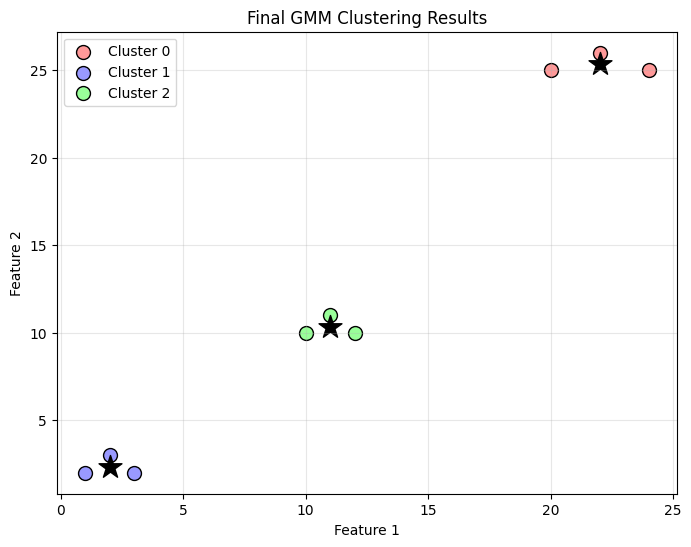

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. RUN THE GMM (Ensure you use the variable name 'final_responsibilities' here)
final_means, final_covs, final_responsibilities, ll_history = gmm_log_likelihood(X, k=3)

# 2. ASSIGN CLUSTERS
# argmax(axis=1) picks the index of the highest probability in each row
cluster_assignments = np.argmax(final_responsibilities, axis=1)

# 3. PRINT RESULTS
print("--- Final Cluster Assignments ---")
for i, cluster in enumerate(cluster_assignments):
    print(f"Point {i} {X[i]} -> Cluster {cluster}")

# 4. VISUALIZE THE FINAL CLUSTERS
plt.figure(figsize=(8, 6))
colors = ['#FF9999', '#9999FF', '#99FF99'] # Soft Red, Blue, Green

for k in range(3):
    # Filter points belonging to the current cluster
    cluster_points = X[cluster_assignments == k]
    
    # Plot points
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                color=colors[k], label=f'Cluster {k}', s=100, edgecolors='k')
    
    # Plot the calculated mean as a star
    plt.scatter(final_means[k, 0], final_means[k, 1], 
                color='black', marker='*', s=300, label=f'Mean {k}' if i==0 else "")

plt.title("Final GMM Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Question 3

### Clustering of Cancer Cell Images

For this question, you are provided with a dataset containing images of cancer cells. You can download the dataset [here](https://www.kaggle.com/datasets/naim99/segmented-images-of-the-skin-cancer-dataset?select=malignant_segmented). These images are pre-labeled into two categories: benign and malignant. However, for this assignment, you must ignore the labels and treat the dataset as unlabeled data for clustering purposes. In particular, I want you to put all images for both benign and malignant categories in one folder and treat them all together in one folder on your path called `cancer_images`. 

Your task is to apply two different clustering approaches of your choice (e.g., K-means, Gaussian Mixture Models, DBSCAN, Agglomerative Clustering, etc.) to identify the underlying structure of the data and analyze how well each clustering method performs in grouping the images.





### 3.1 Preprocess the data

{accuracy: 1}

Run the following code to preproecss and resize the images. After that, display a few images from the dataset.

In [17]:
# Required Libraries
import os
import numpy as np
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from PIL import Image

# Step 1: Define the path to the images folder
image_folder = "cancer_images"

# Step 2: Load and preprocess images
def load_and_preprocess_images(folder, image_size=(64, 64)):
    """
    Loads images from a folder, resizes them, and converts them into a flattened format.
    Args:
        folder (str): Path to the folder containing images.
        image_size (tuple): Desired size to resize the images.
    Returns:
        images (list): List of flattened image arrays.
        filenames (list): List of image filenames.
    """
    images = []
    filenames = []
    for file in os.listdir(folder):
        if file.endswith(('.png', '.jpg', '.jpeg')):  # Support common image formats
            img_path = os.path.join(folder, file)
            img = Image.open(img_path).convert("RGB")  # Convert to RGB
            img = img.resize(image_size)  # Resize image
            img_array = np.array(img).flatten()  # Flatten to 1D array
            images.append(img_array)
            filenames.append(file)
    return np.array(images), filenames

# Load images
image_size = (64, 64)  # Resize all images to 64x64 pixels
image_data, image_filenames = load_and_preprocess_images(image_folder, image_size)

print(f"Loaded {len(image_data)} images with shape {image_data.shape}.")

# Step 3: Normalize the data
image_data_normalized = image_data / 255.0  # Normalize pixel values between 0 and 1



Loaded 1197 images with shape (1197, 12288).


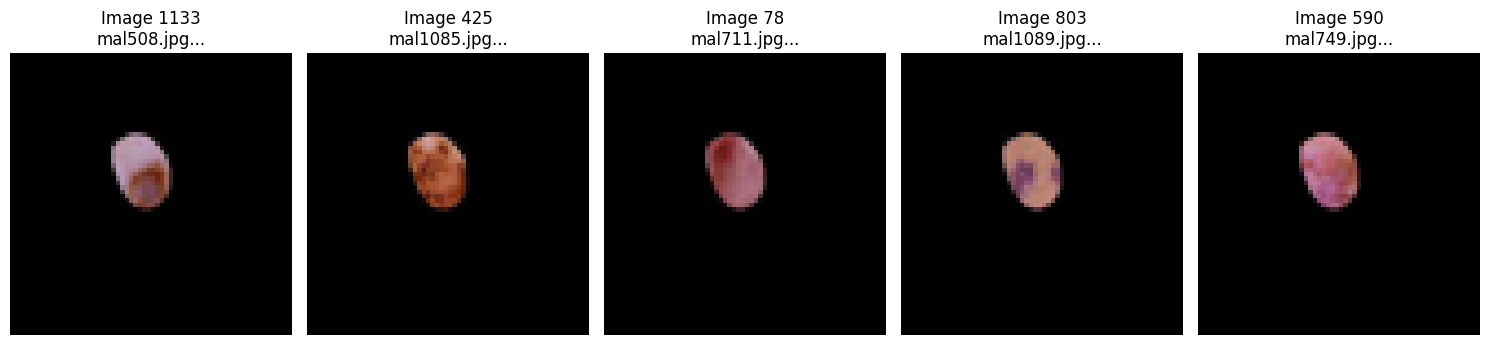

In [18]:
import matplotlib.pyplot as plt

def display_sample_images(data, filenames, num_samples=5):
    """
    Displays a selection of images from the preprocessed dataset.
    """
    plt.figure(figsize=(15, 5))
    
    # Select 5 random indices from the dataset
    indices = np.random.choice(len(data), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        # Reshape the flattened 1D array back to (64, 64, 3)
        img_reshaped = data[idx].reshape(64, 64, 3)
        
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img_reshaped)
        plt.title(f"Image {idx}\n{filenames[idx][:15]}...") # Show first 15 chars of name
        plt.axis('off') # Hide x and y axes for a cleaner look
        
    plt.tight_layout()
    plt.show()

# Execute the display function
display_sample_images(image_data_normalized, image_filenames)

### 3.2 Apply Two Clustering Approaches

{accuracy: 2, reasoning: 2}

Select two clustering algorithms of your choice and justify your selection. Perform clustering on the dataset using both algorithms. Use two clusters since the dataset is known to have two groups (benign and malignant). Also visualize or diaplay the results of some results from each cluster. Do you see any similarities?

Foloowing application of your algorithms, compare the clustering results to the original labels (benign/malignant) using appropriate evaluation metrics such as confision matrix.


--- K-Means Evaluation ---
Accuracy: 0.5322


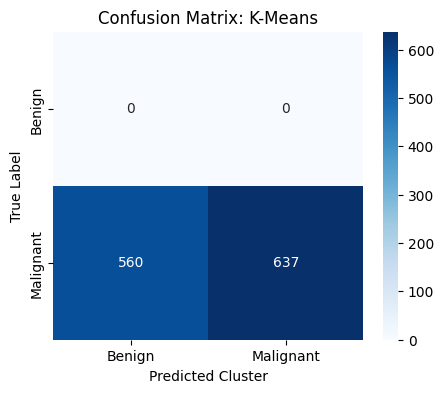


--- GMM Evaluation ---
Accuracy: 0.5681


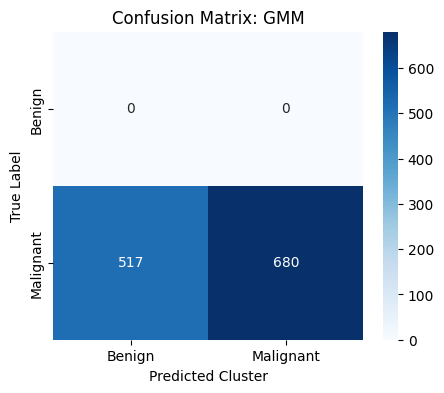

In [19]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import pandas as pd

# Step A: Dimensionality Reduction
pca = PCA(n_components=50, random_state=42)
image_pca = pca.fit_transform(image_data_normalized)

# Step B: Clustering
# 1. K-Means
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(image_pca)

# 2. GMM
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_labels = gmm.fit_predict(image_pca)

# Step C: Extract True Labels from Filenames
# Assuming filenames contain 'benign' or 'malignant'
true_labels = []
for name in image_filenames:
    if 'benign' in name.lower():
        true_labels.append(0)
    else:
        true_labels.append(1)
true_labels = np.array(true_labels)

# Step D: Evaluation Function
def evaluate_clustering(true, pred, method_name):
    # Clustering labels might be flipped (e.g., Cluster 0 = Malignant)
    # This logic aligns cluster IDs with true labels for the best match
    cm = confusion_matrix(true, pred)
    if cm[0,0] + cm[1,1] < cm[0,1] + cm[1,0]:
        pred = 1 - pred # Flip labels if it improves alignment
        cm = confusion_matrix(true, pred)
    
    print(f"\n--- {method_name} Evaluation ---")
    print(f"Accuracy: {accuracy_score(true, pred):.4f}")
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Benign', 'Malignant'], 
                yticklabels=['Benign', 'Malignant'])
    plt.title(f"Confusion Matrix: {method_name}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Cluster')
    plt.show()

evaluate_clustering(true_labels, kmeans_labels, "K-Means")
evaluate_clustering(true_labels, gmm_labels, "GMM")

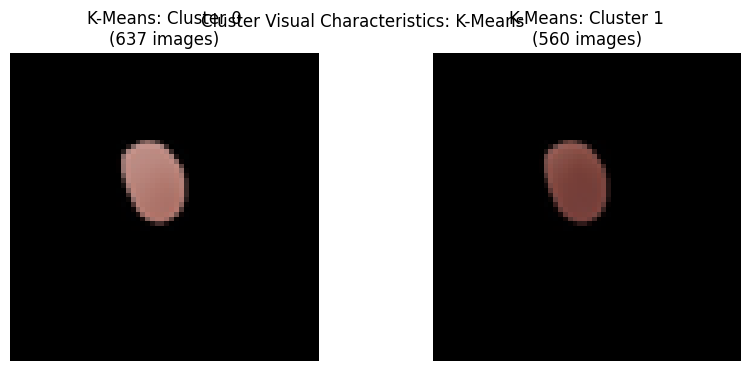

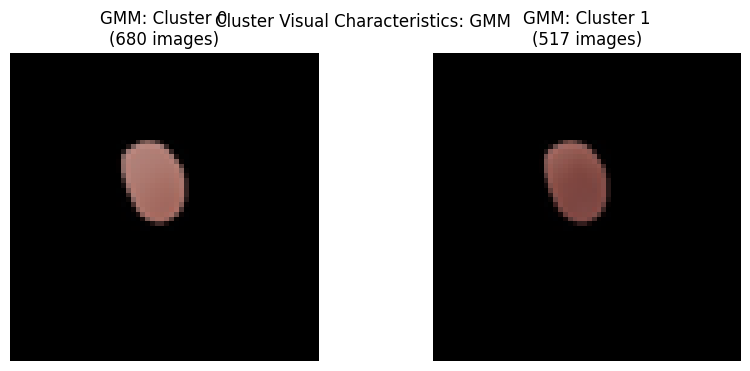

In [20]:
def visualize_cluster_results(data, labels, method_name):
    plt.figure(figsize=(10, 4))
    for i in range(2):
        cluster_indices = np.where(labels == i)[0]
        # Calculate the mean image for the cluster
        mean_img = np.mean(data[cluster_indices], axis=0).reshape(64, 64, 3)
        
        plt.subplot(1, 2, i + 1)
        plt.imshow(mean_img)
        plt.title(f"{method_name}: Cluster {i}\n({len(cluster_indices)} images)")
        plt.axis('off')
    plt.suptitle(f"Cluster Visual Characteristics: {method_name}")
    plt.show()

visualize_cluster_results(image_data_normalized, kmeans_labels, "K-Means")
visualize_cluster_results(image_data_normalized, gmm_labels, "GMM")